# Create a graph with networkx
## Create a graph manually

In [29]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

edge_list = [
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "David"),
    ("Charlie", "David"),
    ("David", "Eve")
]

graph = nx.Graph()
graph.add_edges_from(edge_list)


In [ ]:
# inspect the graph

print("Nodes:", graph.nodes())
print("Edges:", graph.edges())
print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())

In [30]:
print(graph.degree())

[('Alice', 2), ('Bob', 2), ('Charlie', 2), ('David', 3), ('Eve', 1)]


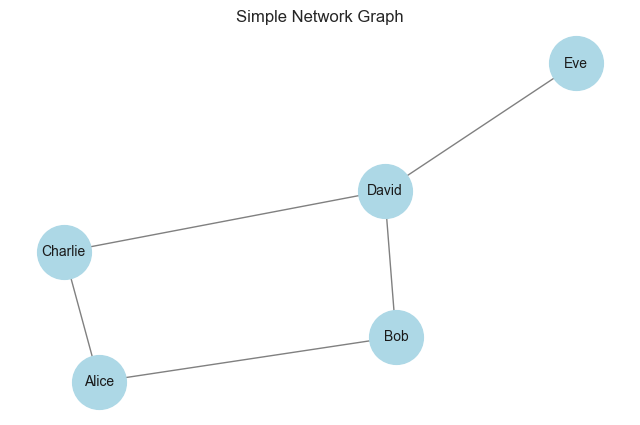

In [7]:

sns.set_theme(style="white", font_scale=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

pos = nx.spring_layout(graph, seed=42)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=1500,
    node_color="lightblue",
    font_size=10,
    edge_color="gray", ax=ax
)

plt.title("Simple Network Graph")
plt.show()

## Create a graph from node tables and edge tables

In [31]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

node_table = pd.read_csv("./data/ai_green_network/node_table_green_ai.csv")
edge_table = pd.read_csv("./data/ai_green_network/edge_table_green_ai.csv")

graph = nx.from_pandas_edgelist(edge_table, source="Source", target="Target", edge_attr="Weight")

size_dict = dict(zip(node_table["Id"], node_table["patent_count"]))
nx.set_node_attributes(graph, size_dict, "size")

In [32]:
# inspect the graph

print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())
print("\nNodes:", graph.nodes())
print("\nEdges:", graph.edges())


Number of nodes: 21
Number of edges: 77

Nodes: ['Batteries', 'AI hardware', 'Knowledge processing', 'Machine learning', 'Planning control', 'Vision', 'Carbon capture and sequestration', 'Climate change adaptation', 'Evolutionary computation', 'Natural language processing', 'Speech', 'Electric vehicles', 'GHG reduction in energy systems', 'Green ICT', 'Green buildings', 'Green industry', 'Green transportation', 'Green waste management', 'Photovoltaics', 'Smart grid', 'Wind motors']

Edges: [('Batteries', 'AI hardware'), ('Batteries', 'Knowledge processing'), ('Batteries', 'Machine learning'), ('Batteries', 'Planning control'), ('Batteries', 'Vision'), ('AI hardware', 'Climate change adaptation'), ('AI hardware', 'Electric vehicles'), ('AI hardware', 'GHG reduction in energy systems'), ('AI hardware', 'Green ICT'), ('AI hardware', 'Green buildings'), ('AI hardware', 'Green industry'), ('AI hardware', 'Green transportation'), ('AI hardware', 'Green waste management'), ('AI hardware', 'Sm

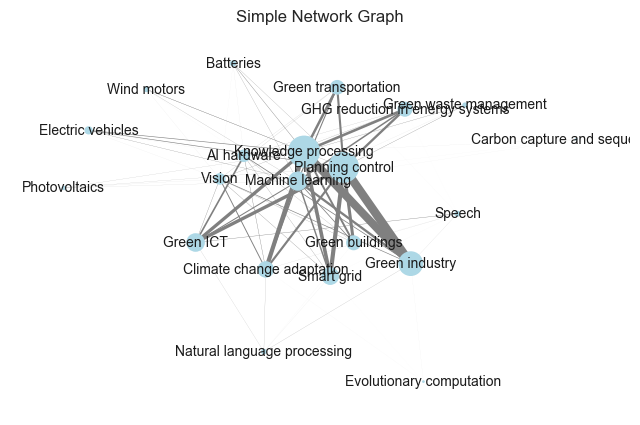

In [33]:
sns.set_theme(style="white", font_scale=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

pos = nx.spring_layout(graph, seed=42)

nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=[graph.nodes[node]["size"]/10 for node in graph.nodes()],
    node_color="lightblue",
    width=[graph[u][v]['Weight']/300 for u, v in graph.edges()],
    font_size=10,
    edge_color="gray", ax=ax
)

plt.title("Simple Network Graph")
plt.show()

In [34]:
communities = list(nx.community.girvan_newman(graph))

# Modularity -> measures the strength of division of a network into modules
modularity_df = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(graph, communities[k])]
        for k in range(len(communities))
    ],
    columns=["k", "modularity"],
)


In [37]:
communities[1]

({'AI hardware',
  'Batteries',
  'Climate change adaptation',
  'Electric vehicles',
  'GHG reduction in energy systems',
  'Green ICT',
  'Green buildings',
  'Green industry',
  'Green transportation',
  'Green waste management',
  'Knowledge processing',
  'Machine learning',
  'Natural language processing',
  'Photovoltaics',
  'Planning control',
  'Smart grid',
  'Speech',
  'Vision',
  'Wind motors'},
 {'Carbon capture and sequestration'},
 {'Evolutionary computation'})